## Importing Libraries 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Loading Dataset

In [3]:
df = pd.read_csv(r'D:\My Course Ai Bin\Machine Learning\Linear\insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape 

(1338, 7)

In [5]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.columns  

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

# Checking Missing Values 

In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Categorical Columns to Numerical 

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(
    df,
    columns=list(categorical_cols),
    drop_first=True
)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Correlation heatmap


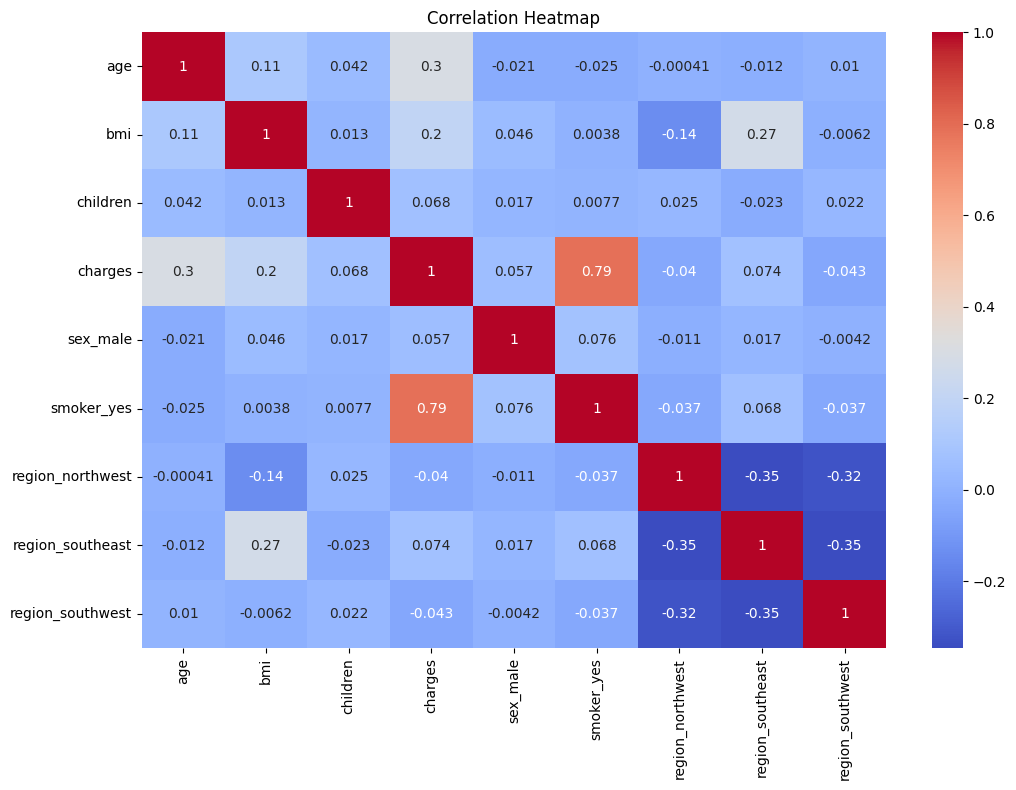

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Distribution graph of insurance charges


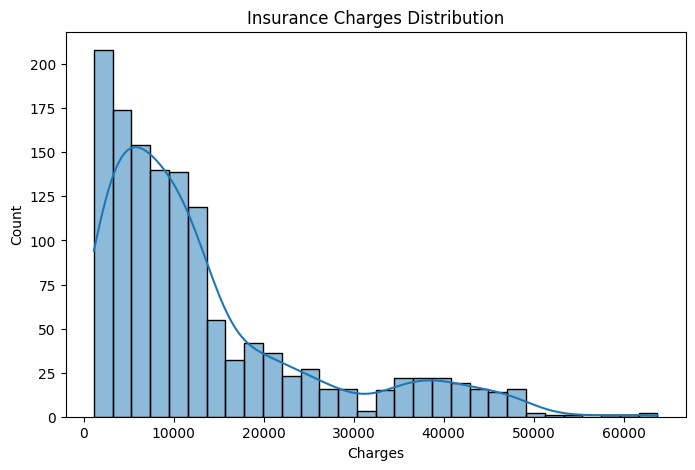

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='charges',
    bins=30,
    kde=True
)
plt.title('Insurance Charges Distribution')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.show()

## Age vs Insurance Charges


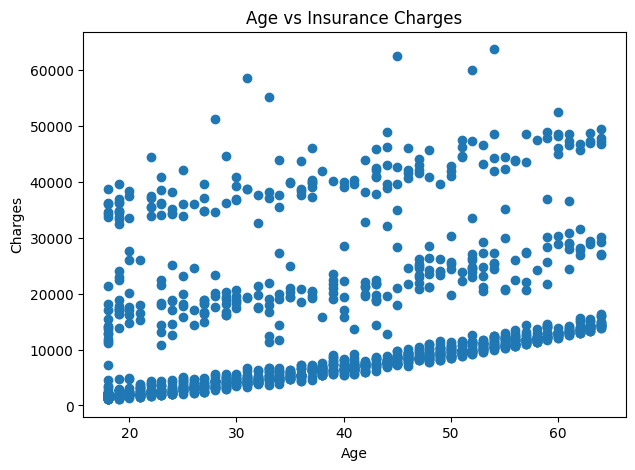

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    df['age'],
    df['charges']
)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

## Input features


In [ ]:
# Input features
X = df.drop('charges', axis=1)

# Target variable
y = df['charges']
print('Features Shape:', X.shape)
print('Target Shape:', y.shape)

Features Shape: (1338, 8)
Target Shape: (1338,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (1070, 8)
Testing Data Shape: (268, 8)


## Model Training 

In [ ]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)
print('Model Training Completed')

Model Training Completed


## Model Prediction 

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Show prediction results
prediction_df = pd.DataFrame({
    'Actual Charges': y_test,
    'Predicted Charges': y_pred
})
prediction_df.head()

,Actual Charges,Predicted Charges
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457


## Calculate Performance Metrics


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Absolute Error: 4181.194473753649
Mean Squared Error: 33596915.85136145
R2 Score: 0.7835929767120724


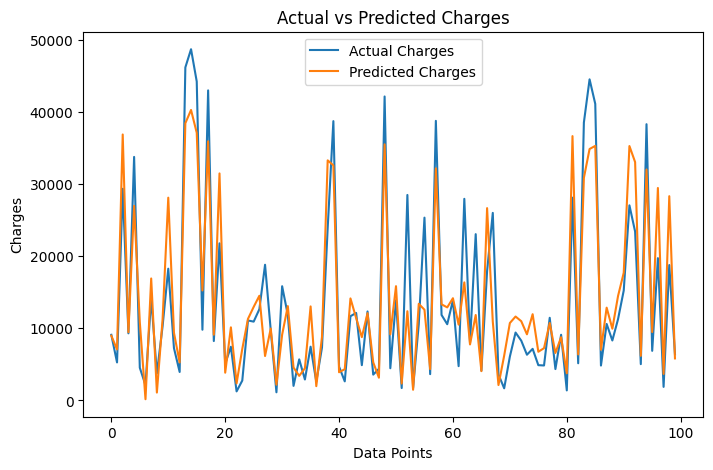

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label='Actual Charges')
plt.plot(y_pred[:100], label='Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.xlabel('Data Points')
plt.ylabel('Charges')
plt.legend()
plt.show()

## Model Coefficients


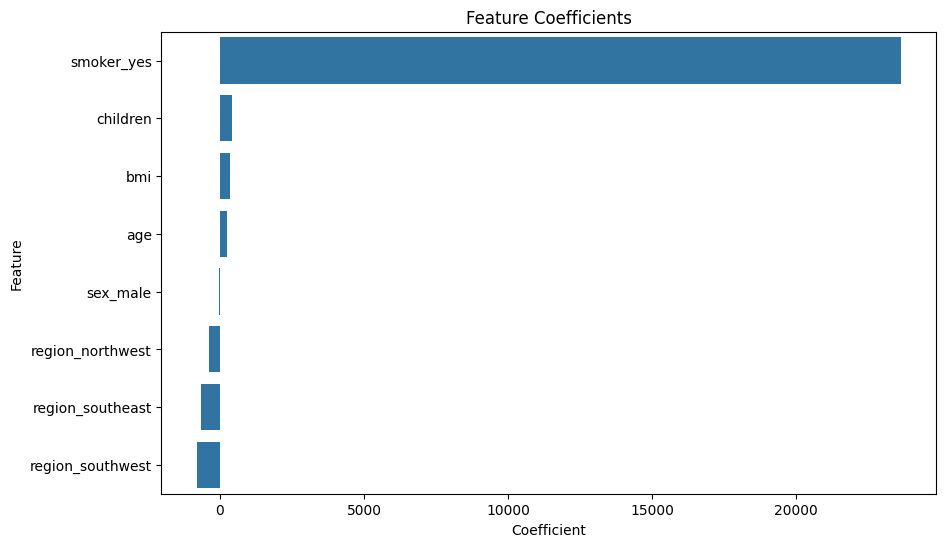

In [ ]:
# Model coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sort values
importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

# Plot graph
plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)
plt.title('Feature Coefficients')
plt.show()

## Predicting Insurance Charges 

In [ ]:
sample_data = X.iloc[[5]]
prediction = model.predict(sample_data)
print('Predicted Insurance Charges:', round(prediction[0], 2))

Predicted Insurance Charges: 4053.93
